## KNN: Water Potability

In [18]:
%pip install pandas matplotlib scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [19]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, silhouette_score

from sklearn.cluster import KMeans

## Water Potability Dataset

In [20]:
df = pd.read_csv('water_potability.csv')
print(df.shape)
print(df.isnull().sum())
df.head()

(3276, 10)
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


## Handle Missing Values

In [21]:
df_clean = df.copy()
df_clean.fillna(df_clean.median(), inplace=True)
print(df_clean.isnull().sum().sum())

0


## Create D1, D2, D3

In [22]:
feature_cols = [c for c in df_clean.columns if c != 'Potability']

D1 = df_clean.copy()

D2 = D1.copy()
D2[feature_cols] = MinMaxScaler().fit_transform(D1[feature_cols])

D3 = D1.copy()
D3[feature_cols] = StandardScaler().fit_transform(D1[feature_cols])

print('D1:', D1.shape)
print('D2:', D2.shape)
print('D3:', D3.shape)

D1: (3276, 10)
D2: (3276, 10)
D3: (3276, 10)


## Check Scaling

In [23]:
print("D1 (Original):")
print(D1[feature_cols].describe().loc[['min', 'max', 'mean']].round(2))

print("\nD2 (MinMax):")
print(D2[feature_cols].describe().loc[['min', 'max', 'mean']].round(2))

print("\nD3 (Standard):")
print(D3[feature_cols].describe().loc[['min', 'max', 'mean']].round(2))

D1 (Original):
         ph  Hardness    Solids  Chloramines  Sulfate  Conductivity  \
min    0.00     47.43    320.94         0.35   129.00        181.48   
max   14.00    323.12  61227.20        13.13   481.03        753.34   
mean   7.07    196.37  22014.09         7.12   333.61        426.21   

      Organic_carbon  Trihalomethanes  Turbidity  
min             2.20             0.74       1.45  
max            28.30           124.00       6.74  
mean           14.28            66.41       3.97  

D2 (MinMax):
        ph  Hardness  Solids  Chloramines  Sulfate  Conductivity  \
min   0.00      0.00    0.00         0.00     0.00          0.00   
max   1.00      1.00    1.00         1.00     1.00          1.00   
mean  0.51      0.54    0.36         0.53     0.58          0.43   

      Organic_carbon  Trihalomethanes  Turbidity  
min             0.00             0.00       0.00  
max             1.00             1.00       1.00  
mean            0.46             0.53       0.48  

D3 (

## Train/Test Split

In [24]:
X1, y1 = D1[feature_cols], D1['Potability']
X2, y2 = D2[feature_cols], D2['Potability']
X3, y3 = D3[feature_cols], D3['Potability']

X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=42)

print(f'Train size: {len(X1_train)} | Test size: {len(X1_test)}')

Train size: 2620 | Test size: 656


## Helper Function

In [25]:
results = {}

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, dataset_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print(f'\n{model_name} on {dataset_name}')
    print(f'Accuracy: {acc:.4f}')
    print(f'Confusion Matrix:\n{cm}')

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Potable', 'Potable'])
    disp.plot(cmap='Blues')
    plt.show()

    return acc

## Decision Tree on D1, D2, D3


Decision Tree on D1 (Original)
Accuracy: 0.5762
Confusion Matrix:
[[254 158]
 [120 124]]


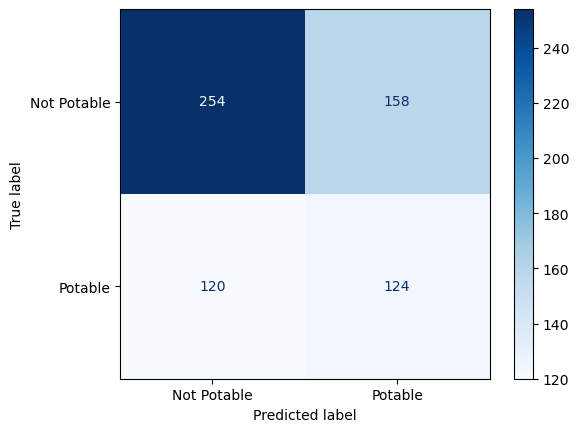


Decision Tree on D2 (MinMax)
Accuracy: 0.5762
Confusion Matrix:
[[254 158]
 [120 124]]


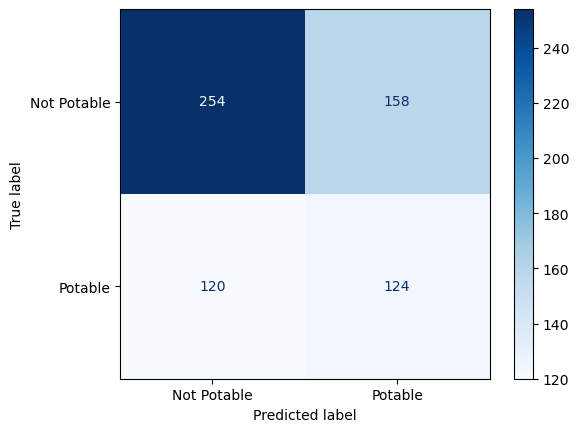


Decision Tree on D3 (Standard)
Accuracy: 0.5762
Confusion Matrix:
[[254 158]
 [120 124]]


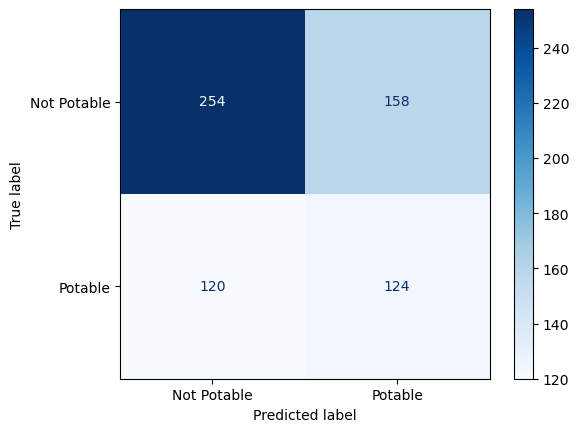

In [26]:
results['DT on D1'] = evaluate_model(DecisionTreeClassifier(random_state=42), X1_train, X1_test, y1_train, y1_test, 'Decision Tree', 'D1 (Original)')
results['DT on D2'] = evaluate_model(DecisionTreeClassifier(random_state=42), X2_train, X2_test, y2_train, y2_test, 'Decision Tree', 'D2 (MinMax)')
results['DT on D3'] = evaluate_model(DecisionTreeClassifier(random_state=42), X3_train, X3_test, y3_train, y3_test, 'Decision Tree', 'D3 (Standard)')

## KNN on D1, D2, D3


KNN on D1 (Original)
Accuracy: 0.5396
Confusion Matrix:
[[294 118]
 [184  60]]


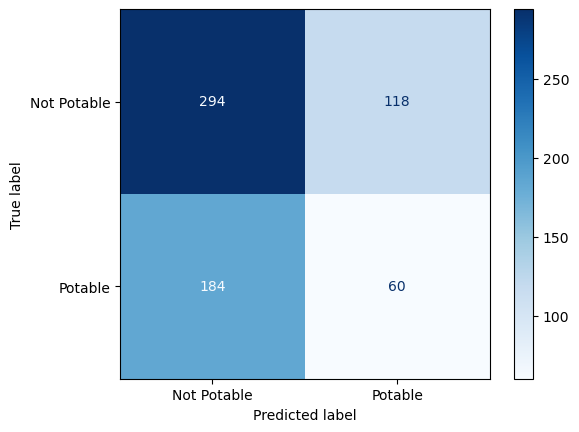


KNN on D2 (MinMax)
Accuracy: 0.6494
Confusion Matrix:
[[327  85]
 [145  99]]


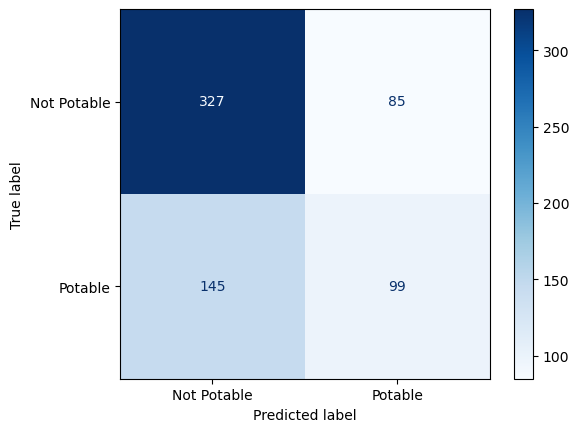


KNN on D3 (Standard)
Accuracy: 0.6311
Confusion Matrix:
[[312 100]
 [142 102]]


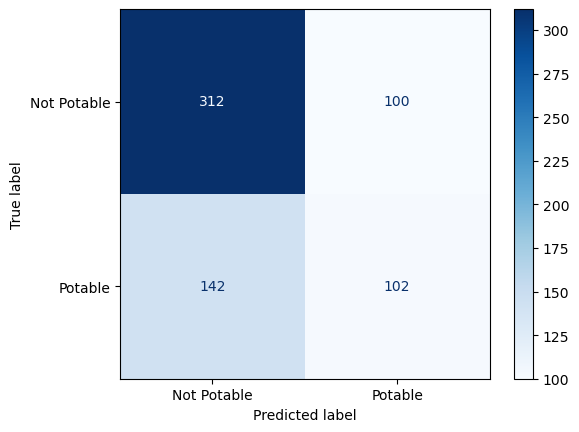

In [27]:
results['KNN on D1'] = evaluate_model(KNeighborsClassifier(n_neighbors=5), X1_train, X1_test, y1_train, y1_test, 'KNN', 'D1 (Original)')
results['KNN on D2'] = evaluate_model(KNeighborsClassifier(n_neighbors=5), X2_train, X2_test, y2_train, y2_test, 'KNN', 'D2 (MinMax)')
results['KNN on D3'] = evaluate_model(KNeighborsClassifier(n_neighbors=5), X3_train, X3_test, y3_train, y3_test, 'KNN', 'D3 (Standard)')

## Classification Summary

    Model  Accuracy
KNN on D2  0.649390
KNN on D3  0.631098
 DT on D1  0.576220
 DT on D2  0.576220
 DT on D3  0.576220
KNN on D1  0.539634

Best Model: KNN on D2 (64.94%)


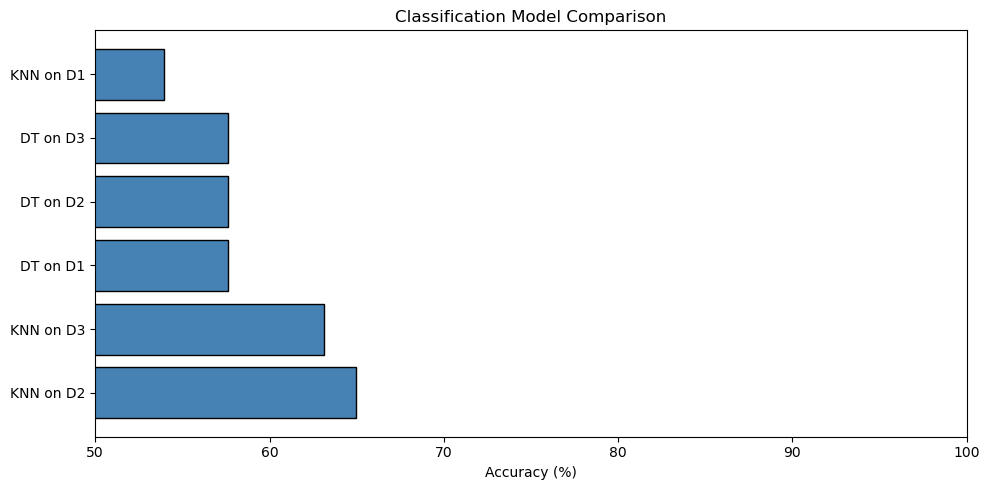

In [28]:
summary = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': list(results.values())
}).sort_values('Accuracy', ascending=False).reset_index(drop=True)

print(summary.to_string(index=False))
print(f'\nBest Model: {summary.iloc[0]["Model"]} ({summary.iloc[0]["Accuracy"]*100:.2f}%)')

plt.figure(figsize=(10, 5))
plt.barh(summary['Model'], summary['Accuracy'] * 100, color='steelblue', edgecolor='black')
plt.xlabel('Accuracy (%)')
plt.title('Classification Model Comparison')
plt.xlim([50, 100])
plt.tight_layout()
plt.show()

## Drop Label for Clustering

In [29]:
C1 = D1.drop(columns=['Potability'])
C2 = D2.drop(columns=['Potability'])
C3 = D3.drop(columns=['Potability'])

## Finding Best K

In [30]:
k_range = range(2, 11)
inertias = []
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(C3)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(C3, km.labels_))
    print(f'K={k} | Inertia: {km.inertia_:,.2f} | Silhouette: {sil_scores[-1]:.4f}')

best_k = k_range[sil_scores.index(max(sil_scores))]
print(f'\nBest K: {best_k} (Silhouette={max(sil_scores):.4f})')

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=13.
  warnings.warn(


K=2 | Inertia: 27,089.65 | Silhouette: 0.0819


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=13.
  warnings.warn(


K=3 | Inertia: 25,359.75 | Silhouette: 0.0766


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=13.
  warnings.warn(


...

K=8 | Inertia: 20,892.47 | Silhouette: 0.0754


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=13.
  warnings.warn(


K=9 | Inertia: 20,385.80 | Silhouette: 0.0754


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=13.
  warnings.warn(


K=10 | Inertia: 19,890.26 | Silhouette: 0.0765

Best K: 2 (Silhouette=0.0819)


## Elbow and Silhouette Plot

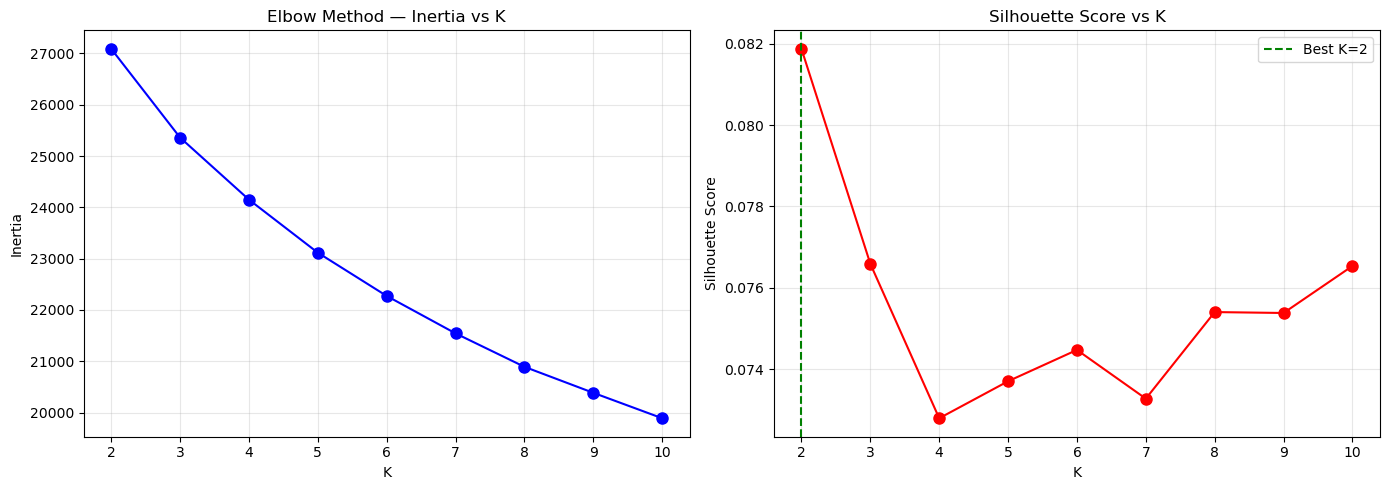

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, 'bo-', markersize=8)
axes[0].set_title('Elbow Method — Inertia vs K')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_range, sil_scores, 'ro-', markersize=8)
axes[1].axvline(x=best_k, linestyle='--', color='green', label=f'Best K={best_k}')
axes[1].set_title('Silhouette Score vs K')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Fit KMeans on All Three

In [32]:
km_c1 = KMeans(n_clusters=best_k, random_state=42, n_init=10)
km_c1.fit(C1)

km_c2 = KMeans(n_clusters=best_k, random_state=42, n_init=10)
km_c2.fit(C2)

km_c3 = KMeans(n_clusters=best_k, random_state=42, n_init=10)
km_c3.fit(C3)

print(f'C1 | Inertia: {km_c1.inertia_:,.2f} | Silhouette: {silhouette_score(C1, km_c1.labels_):.4f}')
print(f'C2 | Inertia: {km_c2.inertia_:,.2f} | Silhouette: {silhouette_score(C2, km_c2.labels_):.4f}')
print(f'C3 | Inertia: {km_c3.inertia_:,.2f} | Silhouette: {silhouette_score(C3, km_c3.labels_):.4f}')

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=13.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=13.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=13.
  warnings.warn(


C1 | Inertia: 89,026,911,507.84 | Silhouette: 0.5760
C2 | Inertia: 431.20 | Silhouette: 0.0968
C3 | Inertia: 27,089.65 | Silhouette: 0.0819


## Scatter Plot

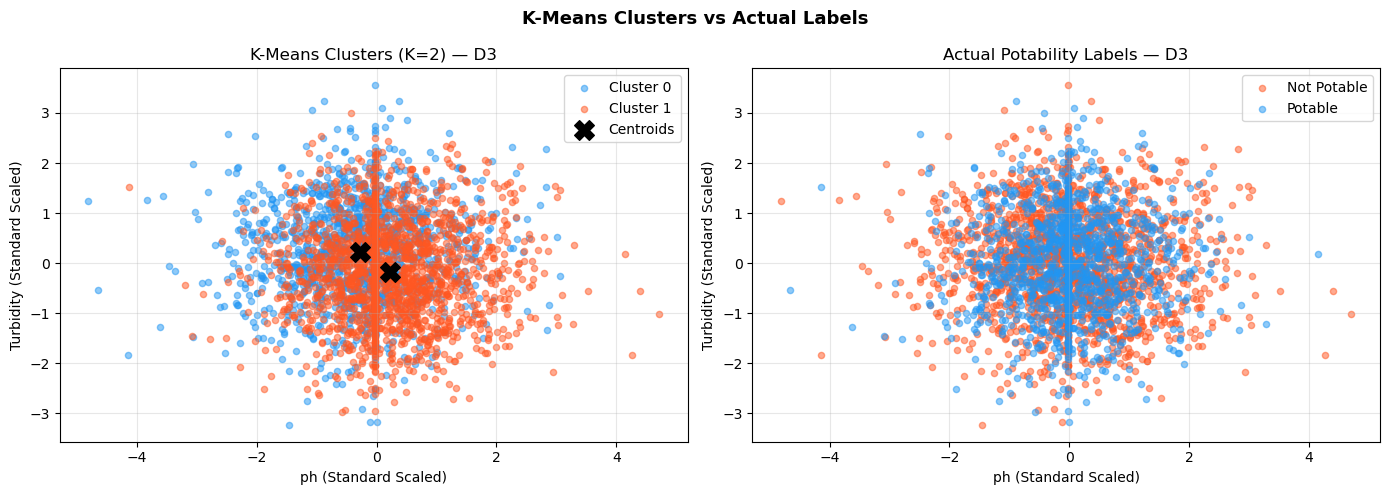

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800']
for i in range(best_k):
    mask = km_c3.labels_ == i
    axes[0].scatter(C3.loc[mask, 'ph'], C3.loc[mask, 'Turbidity'],
                    label=f'Cluster {i}', alpha=0.5, s=20, color=colors[i])

centroids = km_c3.cluster_centers_
ph_idx = list(C3.columns).index('ph')
turb_idx = list(C3.columns).index('Turbidity')
axes[0].scatter(centroids[:, ph_idx], centroids[:, turb_idx],
                marker='X', s=200, color='black', label='Centroids', zorder=5)
axes[0].set_title(f'K-Means Clusters (K={best_k}) — D3')
axes[0].set_xlabel('ph (Standard Scaled)')
axes[0].set_ylabel('Turbidity (Standard Scaled)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for label, color, name in [(0, '#FF5722', 'Not Potable'), (1, '#2196F3', 'Potable')]:
    mask = D3['Potability'] == label
    axes[1].scatter(C3.loc[mask, 'ph'], C3.loc[mask, 'Turbidity'],
                    label=name, alpha=0.5, s=20, color=color)
axes[1].set_title('Actual Potability Labels — D3')
axes[1].set_xlabel('ph (Standard Scaled)')
axes[1].set_ylabel('Turbidity (Standard Scaled)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('K-Means Clusters vs Actual Labels', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()